In [1]:
# 导入 NumPy，用于数组、向量和数值计算。
import numpy as np
# 导入 Matplotlib 的绘图接口 pyplot，用于后面画散点图和辅助线。
import matplotlib.pyplot as plt

In [87]:
# 定义一个函数，用来判断给定点 point 是否落在边长尺度由 R 控制的六边形区域内。
def is_point_in_hexagon(point,R):
    # 取点的 x 坐标绝对值，利用六边形关于 y 轴的对称性简化判断。
    x=np.abs(point[0])
    # 取点的 y 坐标绝对值，利用六边形关于 x 轴的对称性简化判断。
    y=np.abs(point[1])
    # 这是一个较宽松的边界判断写法，目前被注释掉，没有实际参与运行。
    #return x<R*np.sqrt(3)+0.3 and x/2+y*np.sqrt(3)/2<R*np.sqrt(3)+0.3
    # 返回更严格的边界判断结果：同时满足水平边界和斜边边界时，认为点在六边形内部。
    return x<(R-0.5)*np.sqrt(3) and (x/2+y*np.sqrt(3)/2)<(R-0.5)*np.sqrt(3)

In [88]:
# 定义第一条晶格基矢 a1，对应二维三角/蜂窝晶格中的一个方向。
a1=np.array([np.sqrt(3)/2,1/2])
# 定义第二条晶格基矢 a2，对应另一个方向。
a2=np.array([np.sqrt(3)/2,-1/2])
# 设置六边形样品的尺度参数 R。
R=10
# 给出六边形的 6 个顶点坐标，后面虽然没有直接用到，但可用于理解或进一步画边界。
hexagon_vertices=[np.array([0,2*R]),np.array([0,-2*R]),np.array([R*np.sqrt(3),R]),np.array([-R*np.sqrt(3),R]),np.array([R*np.sqrt(3),-R]),np.array([-R*np.sqrt(3),-R])]
# 初始化列表，用于存储所有落在六边形区域内的晶格点。
site=[]
# 在足够大的整数网格范围内枚举 i。
for i in range(-R*2,R*2+1):
    # 在足够大的整数网格范围内枚举 j。
    for j in range(-R*2,R*2+1):
        # 检查位于蜂窝晶格一个子晶格上的点是否在六边形内部。
        if is_point_in_hexagon((i+1/3)*a1+(j+1/3)*a2, R):
            # 如果在内部，就把这个子晶格点加入 site 列表。
            site.append((i+1/3)*a1+(j+1/3)*a2)
        # 检查位于另一个子晶格上的点是否在六边形内部。
        if is_point_in_hexagon((i+2/3)*a1+(j+2/3)*a2, R):
            # 如果在内部，就把第二个子晶格点也加入 site 列表。
            site.append((i+2/3)*a1+(j+2/3)*a2)
# 将 site 从 Python 列表转成 NumPy 数组，方便后续向量化处理和绘图。
site=np.array(site)

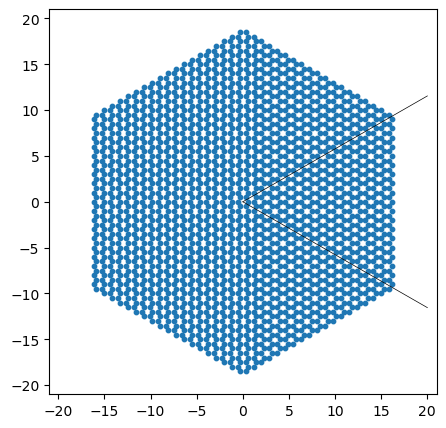

In [90]:
# 创建一个 5x5 英寸的绘图窗口和坐标轴。
fig,ax = plt.subplots(figsize=(5,5))
# 将所有原始晶格点画成散点图，其中横坐标为 x，纵坐标为 y。
ax.scatter(site[:,0],site[:,1],marker='o',s=10)
# 设置 x 轴显示范围，使整个六边形样品都能显示出来。
ax.set_xlim(-2*R-1,2*R+1)
# 设置 y 轴显示范围，使图像上下留出一点边距。
ax.set_ylim(-2*R-1,2*R+1)
# 画出一条从原点出发的正斜率辅助线，可视化 disclination 切除/拼接的边界方向之一。
ax.plot(np.linspace(0,2*R,10),np.linspace(0,2*R,10)/np.sqrt(3),color='black',linewidth=0.5)
# 画出另一条负斜率辅助线，与上一条线共同标记角区范围。
ax.plot(np.linspace(0,2*R,10),-np.linspace(0,2*R,10)/np.sqrt(3),color='black',linewidth=0.5)

In [105]:
# 初始化新的列表，用于存储施加 disclination 变换后的晶格点坐标。
site_disclination=[]
# 遍历原始六边形样品中的每一个晶格点。
for point in site:
    # 计算该点到原点的径向距离 r。
    r=np.sqrt(point[0]**2+point[1]**2)
    # 计算该点的极角 theta，取值范围是 -pi 到 pi。
    theta=np.arctan2(point[1],point[0])
    # 只对位于给定角扇区内的点进行保留和映射，这里对应去掉一个 pi/3 的角区后的几何构造。
    if np.abs(theta)<np.pi*5/6-0.001:
        # 将极角按 6/5 比例拉伸，把原来的 5 份角度重新映射到 6 份角度。
        theta=theta*6/5
        # 将半径也按 6/5 放大，使映射后的点分布与角度拉伸相协调。
        r=r*6/5
        # 把变换后的极坐标重新写回笛卡尔坐标，并加入新点集。
        site_disclination.append(np.array([r*np.cos(theta),r*np.sin(theta)]))
# 将变换后的点集从列表转成 NumPy 数组，便于后续切片和绘图。
site_disclination=np.array(site_disclination)

(-25.0, 25.0)

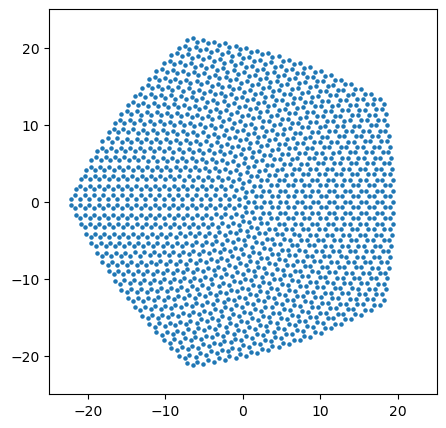

In [106]:
# 再创建一个 5x5 英寸的绘图窗口，用于显示 disclination 变换后的结构。
fig,ax=plt.subplots(figsize=(5,5))
# 将变换后的晶格点画出来，点大小设得更小一些以便观察局部结构。
ax.scatter(site_disclination[:,0],site_disclination[:,1],marker='o',s=5)
# 设置变换后图像的 x 轴范围；由于前面把尺度放大了 6/5，这里范围也相应扩大。
ax.set_xlim(-2*R*6/5-1,2*R*6/5+1)
# 设置变换后图像的 y 轴范围，与 x 轴保持一致的尺度。
ax.set_ylim(-2*R*6/5-1,2*R*6/5+1)

In [54]:
# 试图取出变换后点集的所有 x 坐标。
site_disclination[:,0]
# 这行在某次运行里报错过，是因为当时 site_disclination 还是 Python 列表而不是 NumPy 数组，
# 列表不支持 [:,0] 这种二维切片；只有在上一单元最后成功执行了 np.array 转换后，这样写才有效。

TypeError: list indices must be integers or slices, not tuple

In [ ]:
# 这个代码单元目前是空的，可以留作后续补充分析、调试或绘图。